# Notebook 6 — Sensors, Gestures, and Feature Specificity: a Multi-Modal Journey

> **Learning Objectives**
> - Understand how sensor modality constrains and shapes the features you can compute
> - Understand how gesture type determines which features are most *informative*
> - Build a unified multi-modal analysis pipeline that accommodates different data formats
> - Produce a comparative feature table across sensor types and gesture categories
> - Develop intuition for sensor-feature fit that will guide future research design

## 0. Prerequisites

This notebook assumes you have completed Notebooks 1–5 and are comfortable with:

- `SlidingWindow` creation and the `(Time, Signals, Dimensions)` tensor convention
- `StaticFeature` vs. `DynamicFeature` and window sizing
- The Streaming API (`__call__`) and the Pure Math API (`.compute()`)
- Result dataclasses and `to_flat_dict()`
- The four-layer theoretical framework

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from pyeyesweb.data_models import SlidingWindow
from pyeyesweb.low_level import (
    KineticEnergy, BoundingBoxFilledArea, Smoothness,
    DirectionChange, PointsDensity, GeometricSymmetry
)
from pyeyesweb.mid_level import Suddenness
from pyeyesweb.analysis_primitives import Rarity, StatisticalMoment

from examples.utils.data_loader import GestureDataLoader
from examples.utils.plot_utils import plot_stick_figure_3d, display_video_notebook

## 2. The Three Sensor Modalities

### 2.1 Qualisys Optical Motion Capture

**What it gives you:**
- High-precision 3-D positions of reflective markers in metric coordinates (mm)
- Full skeleton: up to 21–32 joints per trial
- Sampling rate: typically 100–240 Hz
- **Strengths**: gold-standard accuracy, full body, no temporal lag
- **Limitations**: requires controlled lab environment, markers can occlude

**What this enables in PyEyesWeb:**
- All spatial geometry features (`BoundingBoxFilledArea`, `EllipsoidSphericity`, `PointsDensity`, `GeometricSymmetry`) — they require multi-joint 3-D positions
- Full-body `KineticEnergy` with per-joint breakdown
- `Smoothness`, `DirectionChange`, `Suddenness` on any limb or the whole body

### 2.2 Kinect (RGB-D Depth Camera)

**What it gives you:**
- 3-D skeleton positions estimated from depth image (25 joints in Kinect v2)
- Positions in camera-relative metric coordinates
- Sampling rate: ~30 Hz
- **Strengths**: no markers, relatively portable, captures full body
- **Limitations**: lower precision, occlusion sensitivity, lower frame rate

**What this enables in PyEyesWeb:**
- Same spatial geometry and kinematics features as Qualisys — but with reduced precision
- `max_length` for dynamic features may need adjustment for 30 Hz (longer in absolute frames, same in seconds)
- Bilateral symmetry (`GeometricSymmetry`) is particularly well-suited — joint pairs are explicitly labelled

### 2.3 Body-worn IMU

**What it gives you:**
- Linear acceleration (3-axis) and angular velocity (3-axis) from a sensor rigidly attached to a body segment
- No absolute position — only local kinematics
- Sampling rate: typically 50–200 Hz
- **Strengths**: portable, wearable, works outdoors, low cost
- **Limitations**: no global reference frame, no multi-joint spatial geometry, integration drift

**What this enables in PyEyesWeb:**
- `KineticEnergy` from acceleration magnitude (proxy for force, not velocity-squared)
- `Smoothness` on the acceleration magnitude time-series
- `Suddenness` on the wrist or chest acceleration
- **Not available**: `BoundingBoxFilledArea`, `GeometricSymmetry`, `PointsDensity` — all require multi-joint positions


## 3. Sensor-Feature Compatibility Map

Use this map when selecting features for a new experiment or dataset.

| Feature | Qualisys | Kinect | IMU |
|---------|---------|--------|-----|
| `KineticEnergy` | ✅ (velocity) | ✅ (velocity) | ⚠️ (acceleration proxy) |
| `BoundingBoxFilledArea` | ✅ | ✅ | ❌ (no multi-joint positions) |
| `EllipsoidSphericity` | ✅ | ✅ | ❌ |
| `PointsDensity` | ✅ | ✅ | ❌ |
| `GeometricSymmetry` | ✅ | ✅ | ❌ |
| `Smoothness` | ✅ | ✅ (lower Hz) | ✅ (on accel. magnitude) |
| `DirectionChange` | ✅ | ✅ | ⚠️ (requires position integration) |
| `Suddenness` | ✅ | ✅ | ✅ (on velocity magnitude) |
| `Rarity` | ✅ | ✅ | ✅ |


## 4. Gesture-Feature Fit

Beyond sensor compatibility, the **type of movement** determines which features are most discriminant. The following table is a guide based on the expected 25-trial dataset.

| Gesture category | Most informative features | Why |
|-----------------|--------------------------|-----|
| **Ballistic / impulsive strikes** | `KineticEnergy`, `Suddenness`, `Rarity` | Explosive energy peaks; velocity distribution is heavy-tailed |
| **Slow, sustained reaches** | `Smoothness (SPARC)`, `DirectionChange` | Velocity profile should be bell-shaped; trajectory is direct |
| **Repetitive rhythmic gestures** | `StatisticalMoment`, `Synchronization` | Periodic energy; bilateral coordination |
| **Static postures** | `BoundingBoxFilledArea`, `EllipsoidSphericity` | Body volume and shape captured in single frame |
| **Falls / off-balance events** | `Equilibrium`, `PointsDensity` | Centre of mass displacement from base of support |
| **Expressive dance phrases** | All Layer 3 features + `Rarity` | Complex quality over longer timescales |


## 5. Multi-Modal Pipeline Architecture

We design the pipeline to accept any sensor modality by abstracting over the data format:

In [10]:
def compute_feature_row(pos, vel, marker_names, RATE_HZ=100.0, WINDOW_FRAMES=60):
    """
    Compute a single summary row (mean values over trial) for a given pose+velocity tensor.

    Parameters
    ----------
    pos : ndarray (T, N_joints, 3)
        Position tensor.
    vel : ndarray (T, N_joints, 3)
        Velocity tensor (or acceleration for IMU).
    marker_names : list[str]
        Joint labels.
    RATE_HZ : float
        Sampling rate.
    WINDOW_FRAMES : int
        Window length for dynamic features.

    Returns
    -------
    dict
        Feature summary dictionary.
    """
    T       = pos.shape[0]
    N, D    = pos.shape[1], pos.shape[2]

    # Initialise features
    ef   = KineticEnergy(weights=1.0)
    sf   = Smoothness(rate_hz=RATE_HZ, metrics=["sparc"])
    sdn  = Suddenness()
    rar  = Rarity(alpha=0.5)

    # Choose a representative joint for single-joint features
    h_idx = marker_names.index("LWristOut") if "LWristOut" in marker_names else 0
    hand_speed = np.linalg.norm(vel[:, h_idx, :], axis=1)

    # Windows
    sw_vel   = SlidingWindow(max_length=1,             n_signals=N, n_dims=D)
    sw_spd   = SlidingWindow(max_length=WINDOW_FRAMES, n_signals=1, n_dims=1)
    sw_hand  = SlidingWindow(max_length=WINDOW_FRAMES, n_signals=1, n_dims=3)
    sw_ehist = SlidingWindow(max_length=300,           n_signals=1, n_dims=1)

    # — Spatial geometry (offline, using compute() for speed) —
    ci_ft = BoundingBoxFilledArea()
    pd_ft = PointsDensity()
    ci_vals, pd_vals = [], []
    if D == 3:  # Only for skeletal data with 3D positions
        for t in range(T):
            ci_vals.append(ci_ft.compute(pos[t]).contraction_index)
            pd_vals.append(pd_ft.compute(pos[t]).points_density)

    # — Kinematic loop —
    energies, sparcs, suddens, rarities = [], [], [], []

    for t in range(T):
        sw_vel.append(vel[t])
        sw_spd.append(hand_speed[t])
        sw_hand.append(pos[t, h_idx:h_idx+1, :])

        e_val = ef(sw_vel).total_energy
        sw_ehist.append(e_val)
        energies.append(e_val)

        if sw_spd.is_full:
            s = sf(sw_spd)
            if s.is_valid:
                sparcs.append(s.sparc)

        if sw_hand.is_full:
            sd = sdn(sw_hand)
            if sd.is_valid:
                suddens.append(int(sd.is_sudden))

        if sw_ehist.is_full:
            r = rar(sw_ehist)
            if r.is_valid:
                rarities.append(r.rarity)

    row = {
        "n_frames":         T,
        "mean_energy":      np.mean(energies),
        "peak_energy":      np.max(energies),
        "mean_sparc":       np.mean(sparcs) if sparcs else np.nan,
        "pct_sudden":       100 * np.mean(suddens) if suddens else np.nan,
        "mean_rarity":      np.mean(rarities) if rarities else np.nan,
        "mean_contraction": np.mean(ci_vals) if ci_vals else np.nan,
        "mean_density":     np.mean(pd_vals) if pd_vals else np.nan,
    }
    return row

## 6. Running the Comparison: Existing Qualisys Trials

In [11]:
QUALISYS_TRIALS = [
    ("trial10", "qualisys", "Impulsive-1"),
    ("trial11", "qualisys", "Impulsive-2"),
    ("trial12", "qualisys", "Impulsive-3"),
]

# Initialize the unified loader
loader = GestureDataLoader("data")

results = []
for trial_name, sensor, gesture in tqdm(QUALISYS_TRIALS, desc="Processing trials"):
    # Load and explicitly standardize the markers to generic skeletal names
    pos, vel, acc, names = loader.load(trial_name, sensor=sensor, standardize=True)
    row = compute_feature_row(pos, vel, names, RATE_HZ=100.0, WINDOW_FRAMES=60)
    row["sensor"]  = sensor
    row["gesture"] = gesture
    results.append(row)

df = pd.DataFrame(results).set_index(["sensor", "gesture"])
print(df[["mean_energy", "peak_energy", "mean_sparc", "pct_sudden", "mean_contraction"]].to_string())

Processing trials:   0%|          | 0/3 [00:00<?, ?it/s]

                       mean_energy   peak_energy  mean_sparc  pct_sudden  mean_contraction
sensor   gesture                                                                          
qualisys Impulsive-1  6.207591e+05  5.122174e+06   -2.104702   92.485224     976020.841776
         Impulsive-2  2.532240e+05  1.064411e+06   -2.232775   90.142483     974787.014340
         Impulsive-3  5.253975e+06  3.432877e+07   -2.216087   90.720461     990128.277888


## 7. Expanding to Multiple Sensors (Template for the 25-Trial Dataset)

Once your IMU, Kinect, and additional Qualisys trials are available, extend the pipeline using the appropriate loaders. The `compute_feature_row` function will automatically skip spatial geometry for IMU trials (where `N=1` and there is no multi-joint skeleton).

In [ ]:
# TEMPLATE — Using the unified data loader for all sensors

# Initialize the loader (if not already done)
# loader = GestureDataLoader("data")

# --- Kinect trials ---
# KINECT_TRIALS = [
#     ("trial10", "kinect", "Impulsive-1"),
#     ("trial12", "kinect", "Fluid-1"),
# ]
# for trial_name, sensor, gesture in KINECT_TRIALS:
#     pos, vel, acc, names = loader.load(trial_name, sensor=sensor, standardize=True)
#     row = compute_feature_row(pos, vel, names, RATE_HZ=30.0, WINDOW_FRAMES=30)
#     row["sensor"] = sensor; row["gesture"] = gesture
#     results.append(row)

# --- IMU trials ---
# IMU_TRIALS = [
#     ("trial10", "imu", "Impulsive-1"),
# ]
# for trial_name, sensor, gesture in IMU_TRIALS:
#     # Standardizing IMU renames columns to standard sensor locations
#     pos, vel, acc, names = loader.load(trial_name, sensor=sensor, standardize=True)
#     # For IMU: treat acceleration directly as kinematic proxy; no spatial geometry
#     row = compute_feature_row(acc, acc, names, RATE_HZ=200.0, WINDOW_FRAMES=100)
#     row["sensor"] = sensor; row["gesture"] = gesture
#     results.append(row)

## 7.5 Visualizing the Data: Skeletons and Video Fallback
Because we standardise the marker names (e.g., mapping Kinect's `HandTipRight` and Qualisys' `R_Hand` to `HAND_RIGHT`), we can plot standardized 3D stick figures directly inside our notebooks! You can also cross-reference with the video recordings using our IPython widget stream:

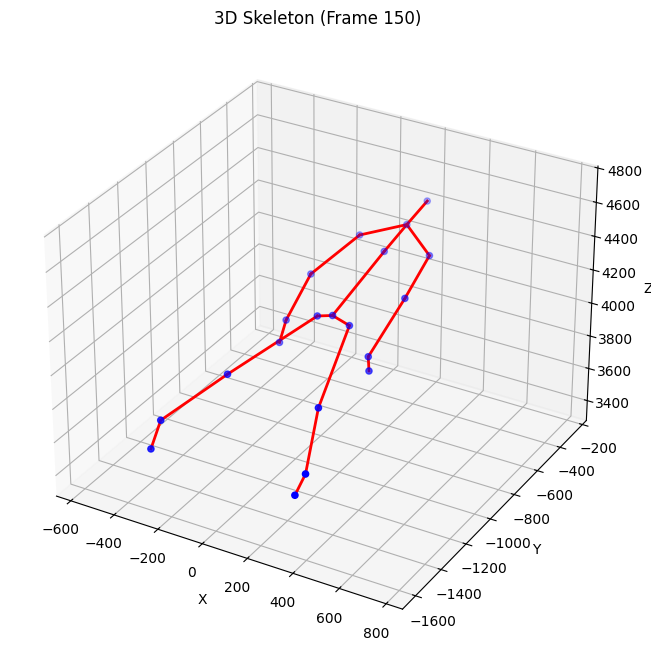

In [12]:
# 1. Show the video for the trial
from pathlib import Path
video_path = Path("data/videos/trial10.avi")
display_video_notebook(video_path)

# 2. Plot the 3D stick figure at a specific frame (ensure standard=True since we loaded with standardize=True)
pos_kinect, _, _, names_kinect = loader.load("trial10", sensor="kinect", standardize=True)
plot_stick_figure_3d(pos_kinect, names_kinect, frame_idx=150, standard=True)

## 8. Comparative Visualisation

Once the full dataset is populated, generate a feature comparison panel:

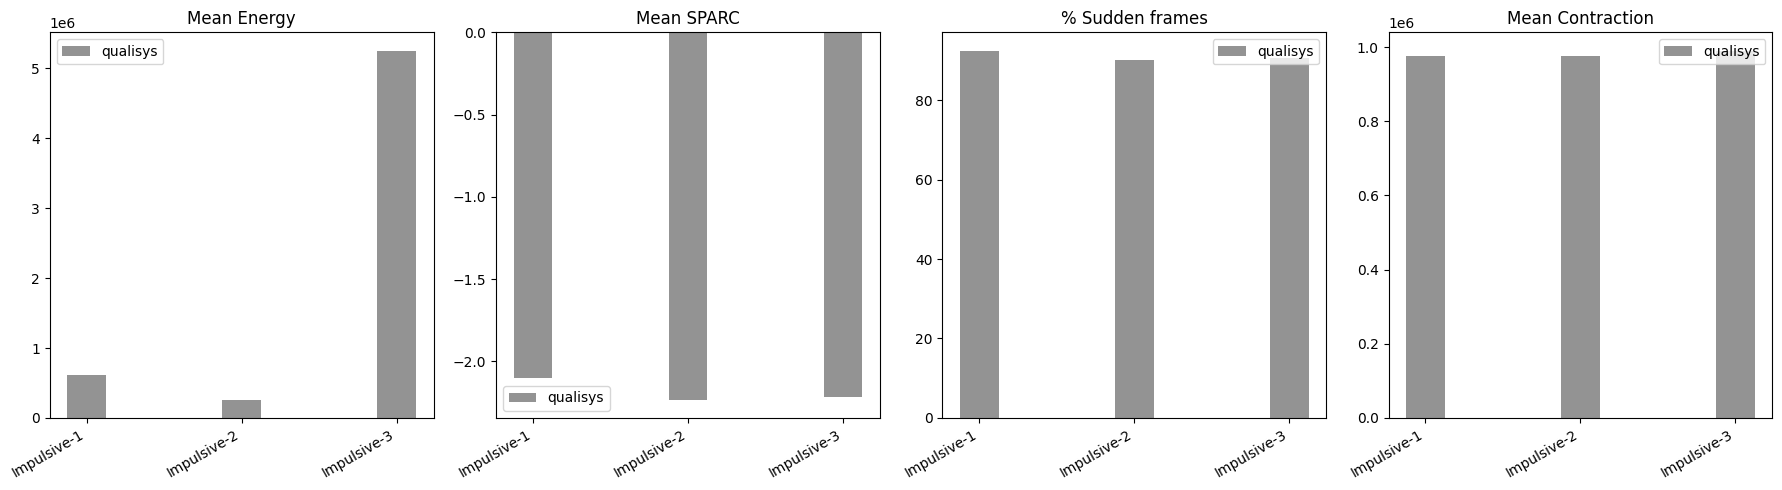

In [13]:
df_full = pd.DataFrame(results)

features_to_plot = ["mean_energy", "mean_sparc", "pct_sudden", "mean_contraction"]
feature_labels   = ["Mean Energy", "Mean SPARC", "% Sudden frames", "Mean Contraction"]

fig, axes = plt.subplots(1, len(features_to_plot), figsize=(18, 5))

sensors  = df_full["sensor"].unique()
gestures = df_full["gesture"].unique()
colors   = {"Qualisys": "steelblue", "Kinect": "seagreen", "IMU": "darkorange"}

for ax, feat, label in zip(axes, features_to_plot, feature_labels):
    for sensor in sensors:
        subset = df_full[df_full["sensor"] == sensor]
        x = range(len(subset))
        ax.bar(
            [i + 0.25 * list(sensors).index(sensor) for i in x],
            subset[feat].fillna(0),
            width=0.25,
            label=sensor,
            color=colors.get(sensor, "grey"),
            alpha=0.85
        )
    ax.set_title(label)
    ax.set_xticks(range(len(gestures)))
    ax.set_xticklabels(gestures, rotation=30, ha="right")
    ax.legend()

plt.tight_layout()
plt.show()

## 9. 🧪 Guided Experiment: Pick One Feature, One Gesture, Three Sensors

**Task**: Choose a gesture type that is recorded across all three sensor modalities (IMU, Kinect, Qualisys). Apply `Smoothness (SPARC)` to all three trials and compare:

In [ ]:
# TEMPLATE — substitute real loaders and file paths when available

# 1. Load the same gesture from each sensor:
# pos_q, vel_q, _, names_q = load_qualisys_tsv("data/qualisys_???_gesture_X.tsv")
# pos_k, vel_k, _, names_k = load_kinect_data("data/kinect_???_gesture_X.???")
# acc_i, gyr_i, names_i    = load_imu_data("data/imu_???_gesture_X.???")

# 2. Apply Smoothness to the right-hand speed of each:
# results_q = ...  # rate_hz=100.0, window=60 frames
# results_k = ...  # rate_hz=30.0,  window=30 frames
# results_i = ...  # rate_hz=200.0, window=100 frames (using accel. magnitude)

# 3. Compare mean SPARC across sensors for the same gesture:
# print(f"Qualisys SPARC: {np.mean(results_q):.3f}")
# print(f"Kinect SPARC  : {np.mean(results_k):.3f}")
# print(f"IMU SPARC     : {np.mean(results_i):.3f}")

**Questions to reflect on:**
1. Is the Kinect SPARC value similar to the Qualisys SPARC for the same gesture? What differences do you expect from the lower frame rate and precision?
2. What does "smoothness" mean when computed from IMU acceleration rather than joint position velocity? Is it the same concept?
3. Does the sensor choice change your interpretation of the movement, or is the feature robust across modalities?

## 10. Building a Trial Gallery (Full 25-Trial Dataset)

When all data is available, produce a complete feature matrix and identify patterns:

In [ ]:
# After running compute_feature_row on all 25 trials:
# df_all = pd.DataFrame(all_results)
# df_all.to_csv("data/full_trial_feature_matrix.csv", index=False)
#
# Explore correlations:
# import seaborn as sns
# sns.pairplot(df_all, hue="sensor", vars=["mean_energy", "mean_sparc", "pct_sudden"])
# plt.show()

## 11. Design Recommendations for Future Experiments

Based on the analysis above, here are practical recommendations for designing movement analysis studies with PyEyesWeb:

| Design question | Recommendation |
|----------------|---------------|
| **Which sensor for spatial posture?** | Qualisys or Kinect — IMU cannot provide multi-joint geometry |
| **Which sensor for movement quality?** | All three — Smoothness and Suddenness work well across modalities |
| **Which window for fast gestures (<0.5 s)?** | Short: 20–30 frames (0.2–0.3 s at 100 Hz) |
| **Which window for phrase-level analysis?** | Long: 200–300 frames (2–3 s at 100 Hz) |
| **How to compare across Qualisys and Kinect?** | Normalize to the same window duration in *seconds* (not frames) by adjusting `max_length` per Hz |
| **How to handle IMU without positions?** | Use acceleration magnitude as a proxy for speed; skip geometry features |

---

## Summary

This capstone notebook has demonstrated:

1. **Sensor-feature compatibility** — not all features are meaningful for all sensors
2. **Gesture-feature fit** — different gestures are best characterised by different layers
3. **A reusable pipeline** (`compute_feature_row`) that abstracts over modality
4. **A comparative framework** for generating feature matrices across sensors and gestures
5. **An experimental scaffold** ready to be populated with the full 25-trial dataset

You now have all the tools to:
- Load motion data from any of the three sensor modalities
- Select appropriate features from the correct theoretical layer
- Extract, structure, and export feature time-series and summary tables
- Compare movement quality across gestures, sensors, and participants


---

## Complete Notebook Journey — Recap

| Notebook | Core concept | Key API |
|----------|-------------|---------|
| NB-1 | SlidingWindow mechanics | `append`, `to_tensor`, `to_flat_array`, `reset`, `max_length` setter |
| NB-2 | Static vs. Dynamic features | `StaticFeature`, `DynamicFeature`, `is_full` guard |
| NB-3 | Dual API | `__call__` (streaming) vs. `.compute()` (offline) |
| NB-4 | Output contracts | `FeatureResult`, `to_flat_dict`, Pandas logging |
| NB-5 | Theoretical framework | 4-layer model, timescale, primitive stacking |
| NB-6 | Multi-modal capstone | Sensor-feature map, pipeline architecture, comparative analysis |
